# **Algunas visualizaciones de attention**

En este notebook exploraremos algunas visualizaciones del modelo de attention a través de [BERT](https://huggingface.co/docs/transformers/model_doc/bert).

BERT es un modelo transformer **encoder-only** ,esto significa que solo usa la mitad "de entender" de la arquitectura completa (sin decoder, sin
generación de texto palabra por palabra).

Fue entrenado por Google, ya con sus pesos ajustados
(pre-entrenado) sobre grandes cantidades de texto

No lo vamos a entrenar nosotros, solo vamos a usar un
modelo que ya aprendió a calcular attention de forma útil.

`bert-base-uncased`:
- **base** = el tamaño más chico de BERT (12 capas,
  12 cabezas por capa)
- **uncased** = no distingue mayúsculas de minúsculas
  ("The" y "the" se tratan igual)

La primera vez que corran esta celda, va a descargar
el modelo desde [HuggingFace](https://huggingface.co/) (una plataforma que aloja modelos pre-entrenados), por lo que puede tardar un poco, es normal.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
!pip install bertviz -q #se corre solo una vez!


In [16]:
#se corre solo una vez para cargar el modelo
from bertviz import head_view
from transformers import BertTokenizer, BertModel

model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("Modelo cargado, listo para usar")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado, listo para usar


# 1. Multi-head attention

El transformer no hace attention una sola vez, la repite en varias capas apiladas

- Layer = en cuál de esas capas estás mirando
(BERT-base tiene 12 capas, apiladas una sobre otra)

- Head = dentro de esa capa, cuál cabeza de multi-head
attention estás mirando
(BERT-base tiene 12 cabezas, en paralelo, dentro de cada capa)

12 capas × 12 cabezas = 144 "vistas" de attention distintas
en todo el modelo

La cabeza roja en la Layer 3 no tiene relación directa
con la cabeza roja en la Layer 8, son patrones independientes

In [17]:
#frase = "The trophy didn't fit in the suitcase because it was too big"
#frase = "The city council refused the demonstrators a permit because they feared violence"
#frase = "The animal didn't cross the street because it was too tired"
frase = "The dog helped the cat because she was very brave"

inputs = tokenizer.encode(frase, return_tensors='pt')
outputs = model(inputs)
attention = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs[0])

head_view(attention, tokens)

<IPython.core.display.Javascript object>

### **Actividad**

1. Escribe tu propia oración con una palabra ambigua
   (que podría referirse a más de una cosa). Reemplaza
   el texto en "oracion" en la celda de arriba

2. Antes de correr, predice a mano a qué palabra debería
   atender esa palabra ambigua

3. Corre la celda. Haz clic en la palabra ambigua en el
   visualizador para ver las líneas de atención

4. Compara: ¿acertaste? ¿Qué cabeza (color) capturó la
   relación que esperabas?

### **Respuestas:**
1. Una de las frases que usaremos es "The dog helped the cat because she was very brave", una frase donde el *she* representa ambiguedad.
2. La palabra *she* representa ambiguedad entre ambos animales.
3.
4. El color rojo capturó la relación entre she y dog. Ciertamente la palabra ambigua "she" está relacionada con dog y era lo que se esperaba.

# 2. Self-attention con pesos reales

Ahora usamos las matrices W_Q, W_K, W_V que BERT realmente
aprendió durante su entrenamiego — el mismo cálculo que ya
programaron a mano, pero con pesos entrenados en vez de
aleatorios.

Prueben cambiar `num_capa` (0 a 11) y comparen los patrones:

- Capas tempranas (0-1): attention más local, o colapsando
  hacia tokens especiales como [CLS]
- Capas intermedias/profundas: patrones distintos, pero
  cuidado: este código combina las 12 cabezas en un solo
  promedio, así que relaciones específicas pueden diluirse acá

Si el resultado no muestra una relación "clara" como en
BertViz, no es un error: significa que esa relación vivía
en UNA cabeza específica, no en el promedio de las 12.


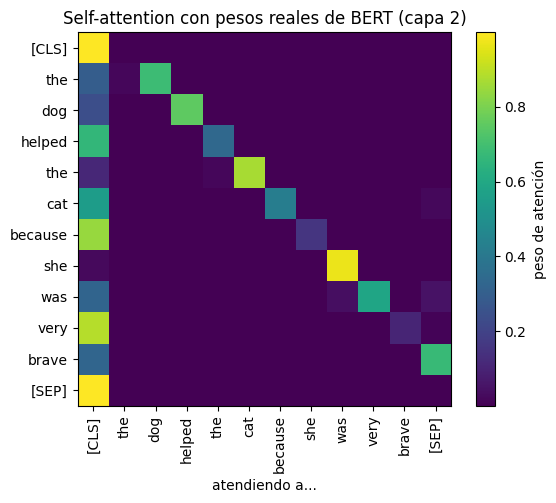

In [18]:
# Elegir qué capa mirar (0 a 11)
num_capa = 2

inputs = tokenizer(frase, return_tensors='pt') #tokenizador de la frasw
outputs = model(**inputs, output_hidden_states=True) #guarda el resultado de cada capa

# hidden_states[0] = embeddings originales (entrada a la capa 0)
# hidden_states[N] = salida de la capa N-1 (entrada a la capa N)
entrada_a_esta_capa = outputs.hidden_states[num_capa].detach().numpy()[0]
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

capa = model.encoder.layer[num_capa].attention.self
#matrices de pesos reales ya entrenados de BERT
W_Q_real = capa.query.weight.detach().numpy()
W_K_real = capa.key.weight.detach().numpy()
W_V_real = capa.value.weight.detach().numpy()

# @ en numpy es el operador de multiplicación de matrices
Q = entrada_a_esta_capa @ W_Q_real.T
K = entrada_a_esta_capa @ W_K_real.T
V = entrada_a_esta_capa @ W_V_real.T

d = Q.shape[1]
#producto punto escalado de attention
scores = (Q @ K.T) / np.sqrt(d)
exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True)) #softmax
pesos_atencion = exp_scores / exp_scores.sum(axis=1, keepdims=True)

#visualización
plt.figure(figsize=(6,5))
plt.imshow(pesos_atencion, cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("atendiendo a...")
plt.colorbar(label="peso de atención")
plt.title(f"Self-attention con pesos reales de BERT (capa {num_capa})")
plt.tight_layout()
plt.show()

### **Observe y responda**

- ¿Hacia qué palabra(s) se concentra la mayor parte de la
  atención en esta capa?
- ¿Es un patrón interpretable (relación de significado) o
  parece attention "colapsando" hacia puntuación/tokens
  especiales?
- Compare con el resultado de otra capa: ¿qué cambió?



### **Respuestas:**
1. En la capa 9, la atención se distribuye hacia estos tokens especiales CLS y SEP.
2. Para este caso, es principalmente un attention colapsando hacia estos tokens especiales. Debido a que BERT ya procesó las relaciones en capas anteriores.
3. En la segunda capa, notamos que *she* está asociado con *was*, dandole mayor peso a la palabra más ambigua. Esto es básicamente la capa más temprana donde se comienza a capturar el contexto de la frase.

# 3. Clasificador de sentimiento

`pipeline("sentiment-analysis")` descarga un modelo ya
entrenado específicamente para una tarea: decidir si un
texto es POSITIVO o NEGATIVO.

Por dentro sigue siendo un transformer (parecido a BERT), con el mismo mecanismo de attention, pero fue
afinado (fine-tuning) con miles de ejemplos de texto
etiquetados como positivo/negativo, hasta aprender a
distinguir el tono de un texto.

El resultado incluye un "label" (POSITIVE o NEGATIVE) y
un "score" (qué tan seguro está el modelo de esa clasificación).

En este caso, usaremos DistilBERT, que está basado en BERT pero es una versión más comprimida.

- BERT-base: 12 capas, 768 dimensiones, ~110 millones de parámetros

- DistilBERT: 6 capas (la mitad), misma dimensión (768),
                 ~66 millones de parámetros
                 → ~40% más chico, ~60% más rápido,
                 conservando ~97% del rendimiento de BERT
                 en varias tareas

In [19]:
from transformers import pipeline

clasificador = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english") #modelo fine-tuned para análisis de sentimiento

#frase="I love how transformers actually make sense now"
#frase = "Of course I love having bad grades"
#frase = "The movie wasn't bad"
frase = "Great, another Monday morning meeting. Just what I needed."

resultado = clasificador(frase)
print(resultado)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9995482563972473}]


### **Actividad**

1. Cambie "frase" por algo suyo; pueden probar una
   frase claramente positiva, una negativa, y una ambigua
   o irónica (ej. "great, another Monday")

2. Observe el "score" (la probabilidad), no solo el
   label. ¿Qué tan seguro está el modelo?

3. Pruebe una oración con sarcasmo o doble sentido.
   ¿El modelo lo detecta, o falla?

### **Respuestas:**
1. Utilizamos la frase irónica "Of course I love having bad grades".
2. Con este ejemplo, el score obtenido es de 99.83%, es decir, que el modelo está bastante seguro de que la frase es clasificada como NEGATIVE.
3. Probando con una oración "Great, another Monday morning meeting. Just what I needed." y el modelo lo detecta como POSITIVE, fallando porque great y needed son usualmente asociadas en contextos positivos.

# 4. Extrayendo embeddings de una oración

`pipeline("feature-extraction")` toma un texto y devuelve
un vector numérico para cada token de esa oración, que es la
representación final que BERT genera después de procesar
toda la oración a través de sus 12 capas.

Estos vectores capturan tanto el significado de cada palabra
como el contexto de las palabras que la rodean. Se usan,
por ejemplo, para comparar qué tan similares son dos textos,
o como entrada para otro modelo que necesite trabajar con
texto ya convertido a números.

El resultado es una matriz: una fila por token, y cada fila
tiene 768 números (el tamaño del vector que usa BERT-base).



In [20]:
extractor = pipeline("feature-extraction", model="bert-base-uncased")

embedding = extractor("The animal didn't cross the street because it was too tired")
print("Forma del embedding:", len(embedding[0]), "(filas) x", len(embedding[0][0]), "(columnas)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Forma del embedding: 15 (filas) x 768 (columnas)


## Qué significa la forma del embedding

**X (filas):** es la cantidad de tokens en que quedó
dividida la oración. No es necesariamente la cantidad de
palabras, BERT tokeniza así:

- Agrega [CLS] al principio y [SEP] al final (2 tokens extra)
- Puede partir una palabra en varios pedazos si no la
  reconoce completa en su vocabulario (ej. "didn't" puede
  quedar dividido en "didn" + "'" + "t")

Por eso el conteo final de tokens casi nunca coincide con
contar palabras separadas por espacios.

**768 (columnas):** es el tamaño del vector de embedding
que BERT-base usa para representar cada token. Es un
número fijo, decidido por quienes diseñaron y entrenaron
este modelo específico, no es un valor universal, otros
modelos usan otros tamaños (BERT-large usa 1024, por
ejemplo).

**Entonces la matriz completa (X x 768)** es: por cada uno
de los 11 tokens de la oración, un vector de 768 números
que lo representa

# 5. Embeddings similares

Este código extrae el vector (embedding) que BERT genera
para la palabra "bank" en dos oraciones distintas:

- "I deposited money at the bank" (banco financiero)
- "We sat by the river bank" (orilla de un río)

`obtener_embedding_palabra` tokeniza la oración, la pasa
por el modelo, encuentra la posición exacta de la palabra
"bank" entre los tokens, y devuelve su vector final.

Después se calcula la similaridad coseno entre ambos
vectores, el resultado es un número entre 0 y 1 que mide qué tan parecidos
son. 1 significa idénticos, 0 significa sin relación.

Si el resultado sale bajo, significa que BERT generó
representaciones distintas para la misma palabra, según
el contexto de cada oración.

In [21]:
def obtener_embedding_palabra(frase, palabra_objetivo):
    inputs = tokenizer(frase, return_tensors='pt')
    outputs = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    idx = tokens.index(palabra_objetivo)
    return outputs.last_hidden_state[0, idx].detach().numpy()

frase1 = "I deposited money at the bank"
frase2 = "We sat by the river bank"

emb1 = obtener_embedding_palabra(frase1, "bank")
emb2 = obtener_embedding_palabra(frase2, "bank")

# Similaridad coseno: 1 = idénticos, 0 = sin relación
similaridad = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
print(f"Similaridad entre 'bank' (financiero) y 'bank' (río): {similaridad:.3f}")

Similaridad entre 'bank' (financiero) y 'bank' (río): 0.726


In [22]:
#Probando con otra frase

frase1 = "She had a cute mole in her cheek"
frase2 = "He has a nice mole poster in his room"

emb1 = obtener_embedding_palabra(frase1, "mole")
emb2 = obtener_embedding_palabra(frase2, "mole")

# Similaridad coseno: 1 = idénticos, 0 = sin relación
similaridad = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
print(f"Similaridad entre 'mole' (lunar) y 'mole' (topo): {similaridad:.3f}")

Similaridad entre 'mole' (lunar) y 'mole' (topo): 0.650


In [23]:
#Probando con la misma palabra y el mismo contexto

frase1 = "He had an accident at the park"
frase2 = "She was taking her dog to the park"

emb1 = obtener_embedding_palabra(frase1, "park")
emb2 = obtener_embedding_palabra(frase2, "park")

# Similaridad coseno: 1 = idénticos, 0 = sin relación
similaridad = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
print(f"Similaridad entre 'park' (parque) en dos contextos: {similaridad:.3f}")

Similaridad entre 'park' (parque) en dos contextos: 0.843


### **Actividad**

1. Elija una palabra en inglés con dos significados
   distintos (ej. "bat" — animal / objeto deportivo,
   "spring" — estación / resorte, "match" — fósforo / partido)

2. Escriba dos oraciones donde esa palabra tenga cada
   significado

3. Reemplace `frase1`, `frase2` y `palabra_objetivo` en
   el código con las suyas, y corra la celda

4. ¿qué tan alta o baja salió la
   similaridad? Tiene sentido?

5. Pruebe también con la **misma** palabra usada dos veces
   con el **mismo** significado, en oraciones distintas
   (ej. "bank" financiero en dos contextos distintos).
   ¿La similaridad sale más alta que en el caso ambiguo?




### **Respuestas:**
1. Con la primera variación, probamos la palabra "mole" en dos contextos distintos, como lunar y como animal.
2.
3.
4. En esta situación, la similaridad que tienen estas palabras con el contexto es bastante baja, de un 65% Tiene sentido que, aunque sea la misma palabra, el contexto otorgue un significado distinto.
5. Probando con la palabra "park" en dos contextos similares, la similaridad es más alta, de un 84.3%

# 6. Context size

Este código muestra el límite real de tokens que BERT puede
procesar de una vez (`tokenizer.model_max_length`).

Después genera un texto artificialmente largo (la misma
oración repetida 1000 veces) y cuenta cuántos tokens resultan
al tokenizarlo.

Si esa cantidad supera el límite del modelo, lo va a indicar
explícitamente. Esto muestra de forma concreta algo que ya
vimos en la teoría: el contexto no es ilimitado, y un texto
real puede superarlo fácilmente.

In [24]:
# Ver el context size real del modelo que ya tienen cargado
print("Context size máximo de BERT:", tokenizer.model_max_length)

# Generar un texto artificialmente largo y ver qué pasa
texto_largo = "El gato come pescado. " * 1000  # se repite 1000 veces

tokens = tokenizer.encode(texto_largo)
print("Cantidad de tokens generados:", len(tokens))

if len(tokens) > tokenizer.model_max_length:
    print("¡Este texto EXCEDE el límite de contexto del modelo!")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8002 > 512). Running this sequence through the model will result in indexing errors


Context size máximo de BERT: 512
Cantidad de tokens generados: 8002
¡Este texto EXCEDE el límite de contexto del modelo!


# **Para las siguientes actividades, use el LLM de su preferencia (ChatGPT, Claude, Gemini, etc)**

## **Actividad: poniendo a prueba el context size**

1. Al empezar una conversación nueva, dile al modelo un
   dato inventado y específico, por ejemplo:
   "Mi número de la suerte es 4173. Recuérdalo."

2. Pégale un texto largo de relleno (puede ser un capítulo
   de Wikipedia, un paper, cualquier texto de varios miles
   de palabras) y pídele que lo resuma.

3. Sigue conversando sobre OTROS temas durante varios
   mensajes más (5-10 intercambios), sin mencionar el
   número de la suerte.

4. Al final, pregúntale: "¿cuál era mi número de la suerte?"

5. ¿lo recordó? ¿Lo recordó mal? Si la conversación
se hizo muy larga, ¿en qué momento empezó a fallar?


**Nota**: los modelos actuales tienen ventanas de contexto
bastante grandes, así que es posible que el modelo SÍ
recuerde el número incluso con texto de relleno largo.
Si eso pasa, pruebe agregando más texto
de relleno, o una conversación más larga, para ver si en
algún punto empieza a fallar.

### **Respuestas:**

5. Utilizando el modelo ChatGPT y tras utilizar 3 papers científicos al azar y 2 mini cuentos relativamente largos finalmente la IA empezó a olvidar parcialmente los detalles. El contexto de estos modelos es gigante, de forma que testear el límite requiere de extender agresivamente la conversación.

## Actividad: probando los límites en la práctica

1. Haz la misma pregunta con un prompt vago y uno claro.
   Compara las respuestas.

2. Pide un dato muy específico que dudas que el modelo
   pueda saber con certeza (un DOI, una fecha exacta, una
   cita textual). ¿Suena igual de seguro que cuando responde
   algo que sí sabe bien?

3. Anota: ¿en qué casos confiarías en la respuesta sin
   verificar, y en cuáles no?

### **Respuestas:**
1. Al preguntar de manera vaga, la respuesta es larga, genérica, y abarca varios puntos sin enfocarse en uno de forma superficial. Sin embargo, al probar un prompt detallado, las respuestas son más específicas y enfocadas.
2. Suena totalmente seguro al dar datos incluso que no maneja, por lo que es muy probable que en conversaciones normales invente información con total confianza. Esta confianza no está relacionada con la veracidad.
3. En contextos donde sea necesaria una respuesta general/vaga, en explicaciones sencillas o incluso en analogías. Sin embargo, cuando necesite de datos específicos, citas, estadísticas o resultado vale la pena y es mejor verificar.